# Assignment 2: Potential Problems in Linear Regression

 This notebook showcases the potential problems associated with using AI tools to generate synthetic when running a linear regression.  

## Issue 1

Problem:

Linear regression assumes the relationship between predictors and the response is a straight line. When the true relationship is curved, the model systematically misses structure in the data. This leads to biased predictions, misleading coefficient interpretations, and residual patterns that violate model assumptions. The textbook emphasizes that if the true relationship is far from linear, “virtually all of the conclusions we draw from the fit are suspect,” and prediction accuracy can drop substantially.

How to detect it:

Residual plots are the primary diagnostic to address this. If residuals show a U‑shape, inverted U, or any or other pattern, the linear model is missing curvature.


How to address it:

Common fixes include adding polynomial terms (ex: x^2), applying transformations (log, sqrt), or using more flexible models. The goal is to allow the model to bend where the data bend.

A question I have: 

How do I know whether to use a polynomial term or a transformation like log(x)?

Answer I found:

Polynomials are best when curvature is symmetric or smooth across the range. Log or square‑root transformations are better when the response changes rapidly at low values and then levels off. We would need compare models using residual plots and cross‑validated error. The model that removes the pattern and improves our generalization is preferred.

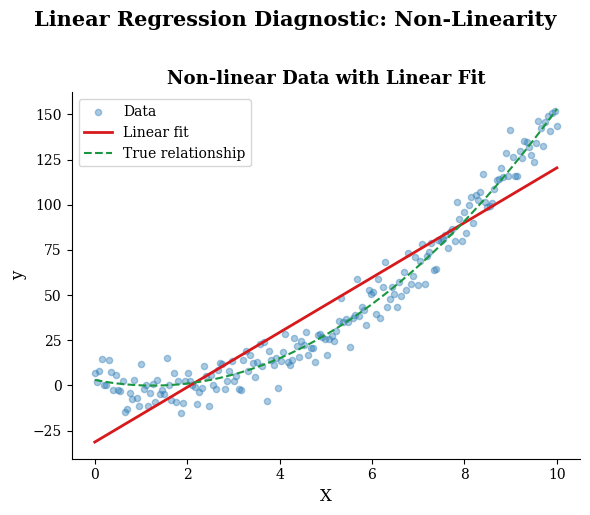

In [13]:
# --- Generate non-linear data ---
np.random.seed(42)
n = 200
X = np.linspace(0, 10, n)
y = 2 * X**2 - 5 * X + 3 + np.random.normal(0, 8, n)
 
# Fit linear regression (misspecified)
model = LinearRegression().fit(X.reshape(-1, 1), y)
fitted = model.predict(X.reshape(-1, 1))
 
# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
 
ax.scatter(X, y, alpha=0.4, s=20, color="#2c7bb6", label="Data")
ax.plot(X, fitted, color="#d7191c", linewidth=2, label="Linear fit")
 
x_true = np.linspace(0, 10, 300)
ax.plot(x_true, 2 * x_true**2 - 5 * x_true + 3, color="#1a9641",
        linewidth=1.5, linestyle="--", label="True relationship")
 
ax.set_xlabel("X", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_title("Non-linear Data with Linear Fit", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
 
fig.suptitle("Linear Regression Diagnostic: Non-Linearity", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("nonlinearity_plot1_fit.png", dpi=150, bbox_inches="tight")
plt.show()
 

This plot was generated with Claude and shows synthetic data with a quadratic relationship. The linear regression line fails to capture the curve in the data, illustrating how a mispecifying a model can systematically underfit non-linear data.

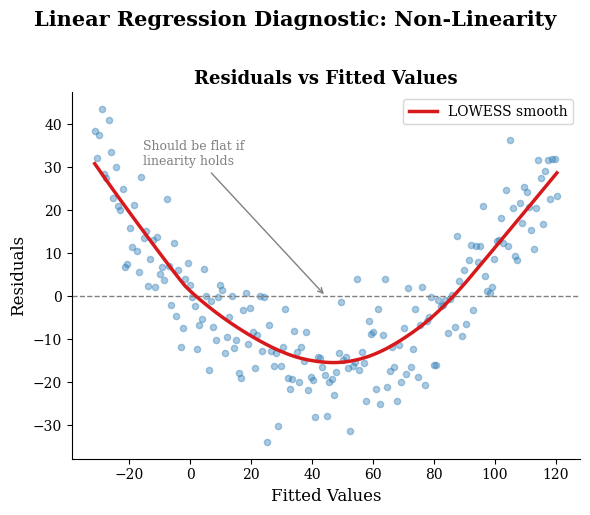

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
 
# --- Generate non-linear data ---
np.random.seed(42)
n = 200
X = np.linspace(0, 10, n)
y = 2 * X**2 - 5 * X + 3 + np.random.normal(0, 8, n)
 
# Fit linear regression (misspecified)
model = LinearRegression().fit(X.reshape(-1, 1), y)
fitted = model.predict(X.reshape(-1, 1))
residuals = y - fitted
 
# LOWESS smooth for residual plot
smoothed = lowess(residuals, fitted, frac=0.4)
 
# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
 
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.scatter(fitted, residuals, alpha=0.4, s=20, color="#2c7bb6")
ax.plot(smoothed[:, 0], smoothed[:, 1], color="#d7191c", linewidth=2.5, label="LOWESS smooth")
 
ax.annotate("Should be flat if\nlinearity holds",
            xy=(fitted.mean(), 0), xytext=(fitted.mean() - 60, residuals.max() * 0.7),
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))
 
ax.set_xlabel("Fitted Values", fontsize=12)
ax.set_ylabel("Residuals", fontsize=12)
ax.set_title("Residuals vs Fitted Values", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
 
fig.suptitle("Linear Regression Diagnostic: Non-Linearity", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("nonlinearity_plot2_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

Claude also generated this residual plot that illustrates an obvious u-shaped pattern of residuals. The LOWESS smooth curve also indicates this. 

## Issue 2

What the problem is & why it matters:
An outlier is an observation whose response value is far from what the model predicts. Outliers can arise from data entry errors, unusual conditions, or model misspecification. Even if an outlier does not drastically change the regression line, it can inflate the residual standard error, distort the R squared and affect inference by widening confidence intervals or altering p‑values. The text shows an example where a single outlier increases the RSE from 0.77 to 1.09.

How to detect it:
Residual plots help identify points with unusually large residuals. One way to identify this is by the studentized residual, which scales each residual by its estimated standard error.

How to address it:
The outlier should be corrected or removed if its due to data error. If it reflects a real but unusual case, we may need a more flexible model or additional predictors. Outliers can possibly reveal a missing variable or structural change in the data.

A question I had:
If an outlier doesn’t change the regression line much, why should I care about it?

Answer I found:
Even when the slope and intercept barely change, outliers can inflate the RSE and distort inference. This affects confidence intervals, hypothesis tests, and the apparent significance of predictors. Outliers can also mask or mimic non‑linearity. So the impact is not only on the fitted line but on the reliability of the whole model.

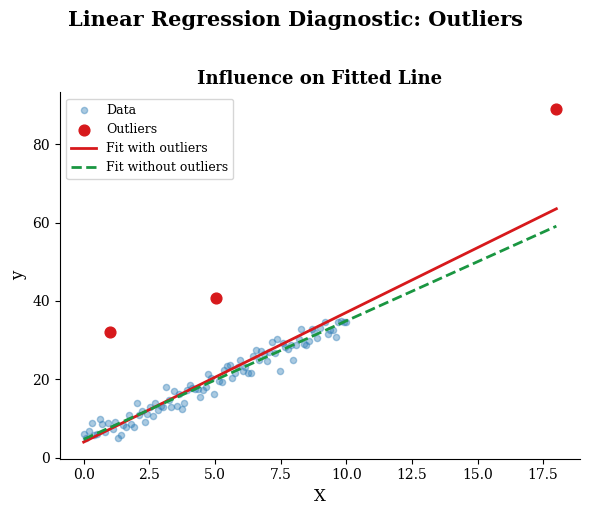

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
 
# --- Generate clean linear data with outliers injected ---
np.random.seed(42)
n = 100
X = np.linspace(0, 10, n)
y = 3 * X + 5 + np.random.normal(0, 2, n)
 
# Inject outliers
outlier_idx = [10, 50, 90]
y[10] += 25
y[50] += 20
X[90] = 18
y[90] = 3 * X[90] + 5 + 30
 
# Fit with and without outliers
model = LinearRegression().fit(X.reshape(-1, 1), y)
 
mask = np.ones(n, dtype=bool)
mask[outlier_idx] = False
model_clean = LinearRegression().fit(X[mask].reshape(-1, 1), y[mask])
 
# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
 
x_line = np.array([X.min(), X.max()])
ax.scatter(X[mask], y[mask], alpha=0.4, s=20, color="#2c7bb6", label="Data")
ax.scatter(X[outlier_idx], y[outlier_idx], s=60, color="#d7191c", zorder=5, label="Outliers")
ax.plot(x_line, model.predict(x_line.reshape(-1, 1)),
        color="#d7191c", linewidth=2, label="Fit with outliers")
ax.plot(x_line, model_clean.predict(x_line.reshape(-1, 1)),
        color="#1a9641", linewidth=2, linestyle="--", label="Fit without outliers")
 
ax.set_xlabel("X", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_title("Influence on Fitted Line", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
 
fig.suptitle("Linear Regression Diagnostic: Outliers", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outliers_plot1_fit.png", dpi=150, bbox_inches="tight")
plt.show()

The second Claude generated plot uses studentized residuals to flag potential outliers. Extreme outlier points are highlighted showing how formal diagnostics can identify influential observations that we may need to investigate a bit more.

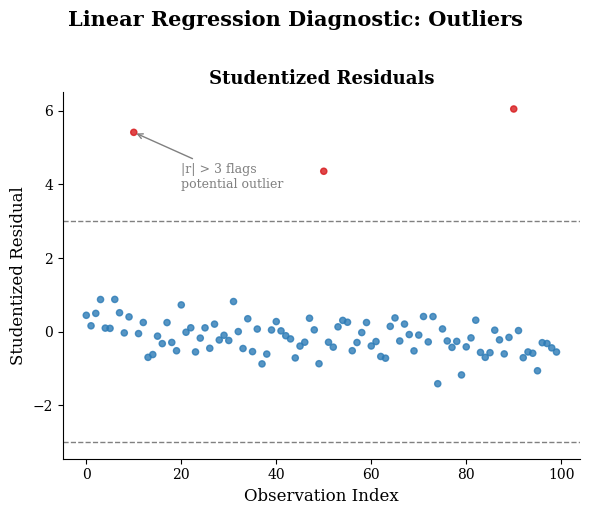

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- Generate clean linear data with outliers injected ---
np.random.seed(42)
n = 100
X = np.linspace(0, 10, n)
y = 3 * X + 5 + np.random.normal(0, 2, n)

# Inject outliers
outlier_idx = [10, 50, 90]
y[10] += 25
y[50] += 20
X[90] = 18
y[90] = 3 * X[90] + 5 + 30

# Fit model and compute studentized residuals
X_2d = X.reshape(-1, 1)
model = LinearRegression().fit(X_2d, y)
fitted = model.predict(X_2d)
residuals = y - fitted

X_mat = np.column_stack([np.ones(n), X])
H = X_mat @ np.linalg.pinv(X_mat.T @ X_mat) @ X_mat.T
h = np.diag(H)
mse = np.sum(residuals**2) / (n - 2)
stud_resid = residuals / np.sqrt(mse * (1 - h))

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

colors = ["#d7191c" if abs(r) > 3 else "#2c7bb6" for r in stud_resid]
ax.axhline( 3, color="gray", linewidth=1, linestyle="--")
ax.axhline(-3, color="gray", linewidth=1, linestyle="--")
ax.scatter(range(n), stud_resid, s=20, alpha=0.8, c=colors)

ax.annotate("|r| > 3 flags\npotential outlier",
            xy=(10, stud_resid[10]), xytext=(20, stud_resid[10] - 1.5),
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Observation Index", fontsize=12)
ax.set_ylabel("Studentized Residual", fontsize=12)
ax.set_title("Studentized Residuals", fontsize=13, fontweight="bold")

fig.suptitle("Linear Regression Diagnostic: Outliers", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outliers_plot2_studentized.png", dpi=150, bbox_inches="tight")
plt.show()

## Issue 3

What the problem is & why it matters:
Collinearity occurs when two or more predictors are highly correlated. When predictors move together, models struggle to separate individual effects. This inflates standard errors, shrinks the t‑statistics, and makes coefficients unstable (small changes in the data can produce large swings in estimated coefficients).

How to detect it:
A correlation matrix can reveal highly correlated pairs, but multicollinearity involving more than two variables requires the Variance Inflation Factor (VIF). A VIF above 5–10 is a common threshold for concern.

How to address it:
You can drop one of the correlated predictors, combine them (e.g., average standardized versions), or use regularized regression (ridge, lasso), which stabilizes coefficients by shrinking them.

A question I had:
If collinearity doesn’t necessarily hurt prediction accuracy, why is it considered a problem?

Answer I found:
Collinearity mainly hurts interpretation but not prediction. If the goal is inference, collinearity makes coefficient estimates unreliable and unstable. But if the goal is prediction, regularized models can handle collinearity. The issue of collinearity depends on whether the overall goal is explanation or prediction.

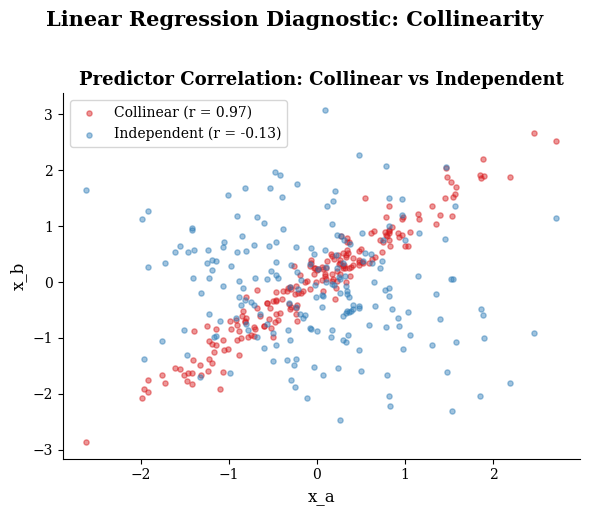

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate collinear and independent predictor pairs ---
np.random.seed(42)
n = 200
x_a     = np.random.normal(0, 1, n)
x_b_col = x_a + np.random.normal(0, 0.25, n)   # collinear  (r ≈ 0.97)
x_b_ind = np.random.normal(0, 1, n)             # independent

r_col = np.corrcoef(x_a, x_b_col)[0, 1]
r_ind = np.corrcoef(x_a, x_b_ind)[0, 1]

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(x_a, x_b_col, s=14, alpha=0.45, color="#d7191c",
           label=f"Collinear (r = {r_col:.2f})")
ax.scatter(x_a, x_b_ind, s=14, alpha=0.45, color="#2c7bb6",
           label=f"Independent (r = {r_ind:.2f})")

ax.set_xlabel("x_a", fontsize=12)
ax.set_ylabel("x_b", fontsize=12)
ax.set_title("Predictor Correlation: Collinear vs Independent", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

fig.suptitle("Linear Regression Diagnostic: Collinearity", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("collinearity_plot1_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

Claude generated this scatterplot to compare a collinear predictor pair with an independent pair. The red points form a somewhat structured diagonal line that indicates strong collinearity, while the blue points are scattered with no obvious pattern. This visual makes the difference between collinear and independent predictors immediately clear.

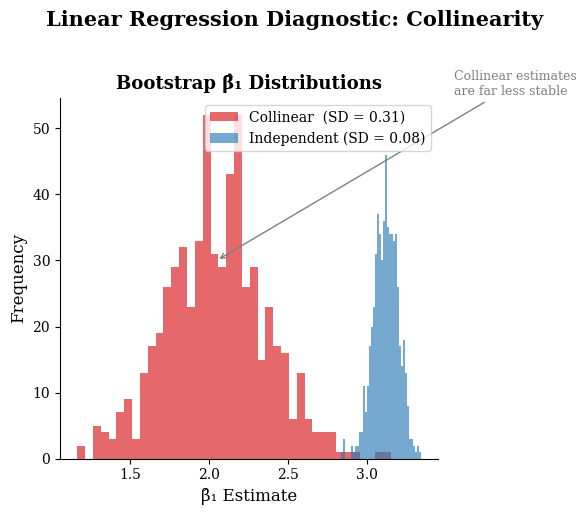

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate data ---
np.random.seed(42)
n = 200
x_a     = np.random.normal(0, 1, n)
x_b_col = x_a + np.random.normal(0, 0.25, n)
x_b_ind = np.random.normal(0, 1, n)
y       = 2 + 1.5 * x_a + 1.5 * x_b_col + np.random.normal(0, 1, n)

X_col = np.column_stack([np.ones(n), x_a, x_b_col])
X_ind = np.column_stack([np.ones(n), x_a, x_b_ind])

def ols(X, y):
    return np.linalg.lstsq(X, y, rcond=None)[0]

# Bootstrap β̂₁ distributions
rng = np.random.default_rng(42)
B = 600
coefs_col, coefs_ind = [], []
for _ in range(B):
    idx = rng.integers(0, n, n)
    coefs_col.append(ols(X_col[idx], y[idx])[1])
    coefs_ind.append(ols(X_ind[idx], y[idx])[1])

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.hist(coefs_col, bins=40, alpha=0.65, color="#d7191c",
        label=f"Collinear  (SD = {np.std(coefs_col):.2f})")
ax.hist(coefs_ind, bins=40, alpha=0.65, color="#2c7bb6",
        label=f"Independent (SD = {np.std(coefs_ind):.2f})")

ax.set_xlabel("β̂₁ Estimate", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Bootstrap β̂₁ Distributions", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)

ax.annotate("Collinear estimates\nare far less stable",
            xy=(np.mean(coefs_col), 30), xytext=(np.mean(coefs_col) + 1.5, 55),
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

fig.suptitle("Linear Regression Diagnostic: Collinearity", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("collinearity_plot2_bootstrap.png", dpi=150, bbox_inches="tight")
plt.show()

This histogram was generated by Claude to illustrate how collinearity affects coefficient stability. The red distribution (collinear predictors) is much wider, showing that beta 1 estimates vary way more when predictors are highly correlated. The blue distribution is narrower, illustrating that independent predictors lead to more stable coefficient estimates.

## Generative AI Reflection

For this assignment I used Claude to generate synthetic datasets and plotting code for each of the three regression issues. My prompts were pretty direct. For example, I asked Claude to “generate synthetic data that clearly shows non‑linearity and produce both a fitted‑line plot and a residual plot,” and it usually produced working code within one or two iterations. The main mistakes I encountered were extra plots I didn’t need, overly complicated diagnostics, or code that didn’t really match the exact structure I wanted. I identified this by running each cell and checked whether the output aligned with the issue I was trying to illustrate. In a few cases, like the outlier example, Claude added additional diagnostics like Cook’s distance that I chose to remove. Overall, the AI sped up the process of generating clean, illustrative examples, but I still needed to review the outputs carefully and make small edits to ensure the plots matched the concepts from the textbook.